In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
# Load Dataset
path='/Users/a.omair/Documents/University/3rd year, 2nd term/ARTI 308 - Machine learning/Lab/Walmart_Sales.csv'
df = pd.read_csv(path)

# Display first 10 rows
df.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [3]:
df.dtypes

Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.dtypes

Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [5]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [10]:
df_missing = df.copy()
df_missing.loc[0:5, 'Weekly_Sales'] = np.nan
df_missing.isna().sum()

Store           0
Date            0
Weekly_Sales    6
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [12]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (6435, 8)
After removing some values:  (6435, 8)


In [13]:
df_missing.head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,NaN,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,NaN,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,NaN,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,NaN,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,NaN,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12,NaN,0,57.79,2.667,211.380643,8.106
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808


In [16]:
df_removed = df_missing.dropna()
df_removed.shape

(6429, 8)

In [17]:
df_removed.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

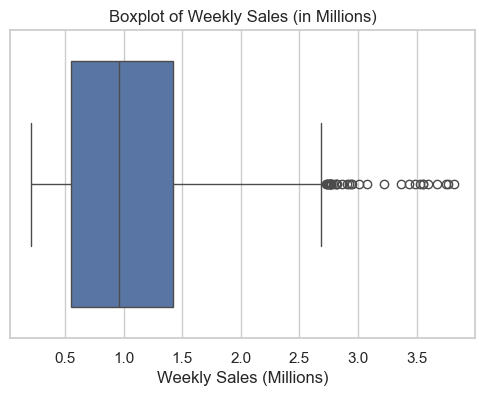

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Weekly_Sales'] / 1_000_000)
plt.title("Boxplot of Weekly Sales (in Millions)")
plt.xlabel("Weekly Sales (Millions)")
plt.show()

In [22]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Weekly_Sales'] < lower) | (df['Weekly_Sales'] > upper)]

outliers.head(15)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
523,4,2011-11-25,3004702.33,1,47.96,3.225,129.836400,5.143
526,4,2011-12-16,2771397.17,0,36.44,3.149,129.898065,5.143
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
761,6,2010-12-24,2727575.18,0,55.07,2.886,212.916508,7.007
1329,10,2010-11-26,2939946.38,1,55.33,3.162,126.669267,9.003


In [23]:
df_no_outliers = df[(df['Weekly_Sales'] >= lower) & (df['Weekly_Sales'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (6435, 8)
After removing outliers:  (6401, 8)


In [24]:
lower_cap = df['Weekly_Sales'].quantile(0.05)
upper_cap = df['Weekly_Sales'].quantile(0.95)

df_capped = df.copy()
df_capped['Weekly_Sales'] = df_capped['Weekly_Sales'].clip(lower_cap, upper_cap)

In [28]:
df[['Weekly_Sales', 'Temperature']].head()

,Weekly_Sales,Temperature
0,1643690.90,42.31
1,1641957.44,38.51
2,1611968.17,39.93
3,1409727.59,46.63
4,1554806.68,46.50


In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['Weekly_Sales', 'Temperature']].copy()

df_scaled[['Weekly_Sales', 'Temperature']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Weekly_Sales,Temperature
0,0.397291,0.434149
1,0.396811,0.396967
2,0.388501,0.410861
3,0.332458,0.476419
4,0.372661,0.475147


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Weekly_Sales', 'Temperature']].copy()

df_standardized[['Weekly_Sales', 'Temperature']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Weekly_Sales,Temperature
0,1.057420,-0.995136
1,1.054348,-1.201170
2,1.001206,-1.124178
3,0.642828,-0.760907
4,0.899914,-0.767955


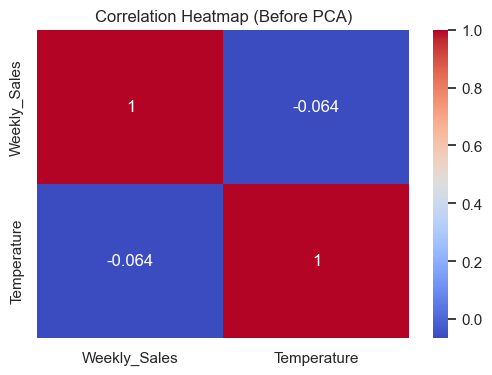

In [31]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Weekly_Sales','Temperature']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [32]:
from sklearn.decomposition import PCA

X = df_standardized[['Weekly_Sales', 'Temperature']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.53190501 0.46809499]


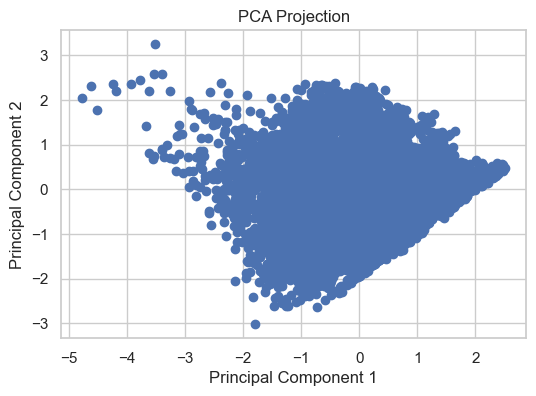

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()